## Step 1 — Setup

All required libraries are imported here. Random seeds are fixed to ensure
results are reproducible — running the notebook twice produces the same output.

In [1]:
# Install / upgrade packages if needed
# !pip install tensorflow numpy matplotlib seaborn scikit-learn --quiet

import os
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

# ── Class names ──────────────────────────────────────────────────────────────
CLASS_NAMES = [
    'T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle Boot'
]

# ── Output directories ───────────────────────────────────────────────────────
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models',  exist_ok=True)

print('Setup complete!')

TensorFlow version : 2.21.0
NumPy version      : 2.2.6
GPU available      : False
Setup complete!


## Step 2 — Load & Explore the Data

Fashion-MNIST contains **70,000 grayscale images** across 10 clothing categories.
The dataset is built into Keras — no manual download required.
We explore shapes, class balance, and visual appearance before any preprocessing.

In [2]:
# ── Load Fashion-MNIST ───────────────────────────────────────────────────────
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = \
    keras.datasets.fashion_mnist.load_data()

# ── Save to data/ ──────────────────────────────────────────────
os.makedirs('../data', exist_ok=True)
np.savez_compressed('../data/train.npz', X=X_train_raw, y=y_train_raw)
np.savez_compressed('../data/test.npz',  X=X_test_raw,  y=y_test_raw)
print('Dataset saved to data/')

print('Dataset loaded successfully!')
print('=' * 44)
print(f'Training images   : {X_train_raw.shape}')
print(f'Training labels   : {y_train_raw.shape}')
print(f'Test images       : {X_test_raw.shape}')
print(f'Test labels       : {y_test_raw.shape}')
print(f'Pixel range       : [{X_train_raw.min()}, {X_train_raw.max()}]')
print(f'Data type         : {X_train_raw.dtype}')
print(f'Number of classes : {len(CLASS_NAMES)}')

Dataset saved to data/
Dataset loaded successfully!
Training images   : (60000, 28, 28)
Training labels   : (60000,)
Test images       : (10000, 28, 28)
Test labels       : (10000,)
Pixel range       : [0, 255]
Data type         : uint8
Number of classes : 10


In [3]:
# ── Inspect one sample ───────────────────────────────────────────────────────
idx = 0
print(f'Sample index   : {idx}')
print(f'Label (number) : {y_train_raw[idx]}')
print(f'Label (name)   : {CLASS_NAMES[y_train_raw[idx]]}')
print(f'Image shape    : {X_train_raw[idx].shape}')
print(f'Min pixel      : {X_train_raw[idx].min()}')
print(f'Max pixel      : {X_train_raw[idx].max()}')
print(f'Mean pixel     : {X_train_raw[idx].mean():.2f}')
print()
print('Top-left 6x6 pixel values (raw):')
print(X_train_raw[idx][:6, :6])

Sample index   : 0
Label (number) : 9
Label (name)   : Ankle Boot
Image shape    : (28, 28)
Min pixel      : 0
Max pixel      : 255
Mean pixel     : 97.25

Top-left 6x6 pixel values (raw):
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


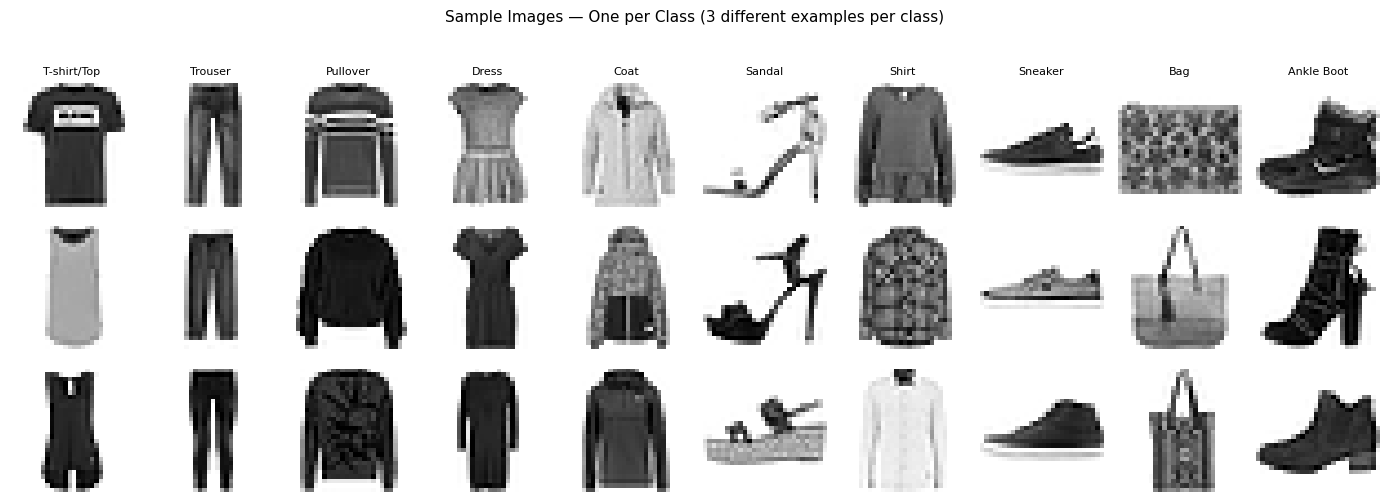

Saved: outputs/sample_images.png


In [4]:
# ── Visualise sample images — 3 rows x 10 classes ───────────────────────────
fig, axes = plt.subplots(3, 10, figsize=(14, 5))
fig.suptitle('Sample Images — One per Class (3 different examples per class)',
             fontsize=11, y=1.02)

for row in range(3):
    for col in range(10):
        sample_idx = np.where(y_train_raw == col)[0][row]
        axes[row, col].imshow(X_train_raw[sample_idx], cmap='gray_r')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(CLASS_NAMES[col], fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/sample_images.png')

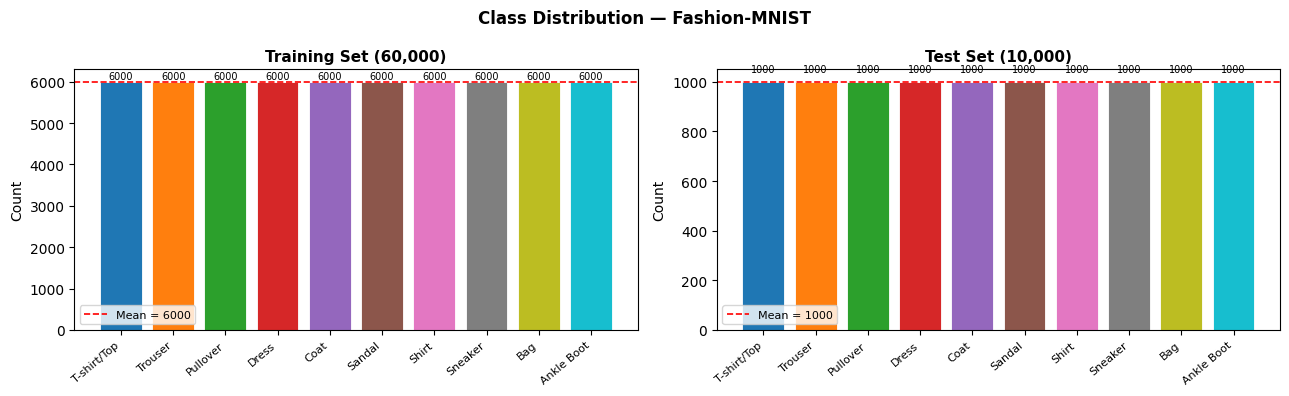

Dataset is perfectly balanced — 6,000 train / 1,000 test per class.
Saved: outputs/class_distribution.png


In [5]:
# ── Class distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, labels, title in zip(
    axes,
    [y_train_raw, y_test_raw],
    ['Training Set (60,000)', 'Test Set (10,000)']
):
    counts = np.bincount(labels)
    bars   = ax.bar(CLASS_NAMES, counts,
                    color=plt.cm.tab10.colors, edgecolor='white', linewidth=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=8)
    ax.axhline(y=counts.mean(), color='red', linestyle='--',
               linewidth=1.2, label=f'Mean = {counts.mean():.0f}')
    ax.legend(fontsize=8)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 30,
                str(count), ha='center', va='bottom', fontsize=7)

plt.suptitle('Class Distribution — Fashion-MNIST', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Dataset is perfectly balanced — 6,000 train / 1,000 test per class.')
print('Saved: outputs/class_distribution.png')

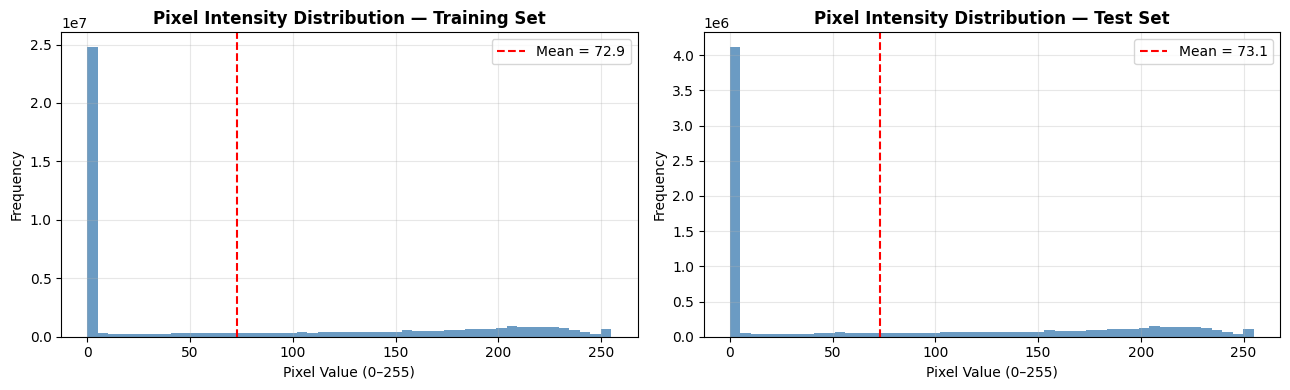

Saved: outputs/eda_pixel_distribution.png


In [6]:
# ── Pixel intensity distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, data, title in zip(
    axes,
    [X_train_raw.flatten(), X_test_raw.flatten()],
    ['Training Set', 'Test Set']
):
    ax.hist(data, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(f'Pixel Intensity Distribution — {title}', fontweight='bold')
    ax.set_xlabel('Pixel Value (0–255)')
    ax.set_ylabel('Frequency')
    ax.axvline(data.mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'Mean = {data.mean():.1f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/eda_pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/eda_pixel_distribution.png')

## Step 3 — Preprocessing

Before feeding images into LeNet-5 we perform three steps:
1. **Normalize** pixel values from `[0, 255]` to `[0.0, 1.0]` for stable gradient updates
2. **Reshape** images from `(28, 28)` to `(28, 28, 1)` to add the channel dimension required by `Conv2D`
3. **One-hot encode** labels for use with Categorical Crossentropy loss

We also **shuffle** the training data before splitting so the validation set is representative of all classes.

Data Quality Checking

In [7]:
# Data Quality Checks ──────────────────────────────────────────────────
import hashlib

print('DATA QUALITY REPORT')
print('=' * 55)

# ── 1. Shape & dtype ─────────────────────────────────────────────
print('\n[1] Shape & Data Type')
print(f'  X_train : {X_train_raw.shape}   dtype={X_train_raw.dtype}')
print(f'  X_test  : {X_test_raw.shape}    dtype={X_test_raw.dtype}')
print(f'  y_train : {y_train_raw.shape}       dtype={y_train_raw.dtype}')
print(f'  y_test  : {y_test_raw.shape}        dtype={y_test_raw.dtype}')

# ── 2. Missing / corrupted images ────────────────────────────────
print('\n[2] Missing / Corrupted Images')
black_train = np.sum(np.all(X_train_raw.reshape(60000,-1)==0, axis=1))
black_test  = np.sum(np.all(X_test_raw.reshape(10000,-1)==0,  axis=1))
white_train = np.sum(np.all(X_train_raw.reshape(60000,-1)==255, axis=1))
white_test  = np.sum(np.all(X_test_raw.reshape(10000,-1)==255,  axis=1))
nan_train   = np.isnan(X_train_raw.astype(float)).sum()
nan_test    = np.isnan(X_test_raw.astype(float)).sum()

print(f'  Black images  (train/test) : {black_train} / {black_test}')
print(f'  White images  (train/test) : {white_train} / {white_test}')
print(f'  NaN values    (train/test) : {nan_train}   / {nan_test}')

# ── 3. Duplicate images ───────────────────────────────────────────
print('\n[3] Duplicate Images')
train_hashes = [hashlib.md5(img.tobytes()).hexdigest() for img in X_train_raw]
test_hashes  = [hashlib.md5(img.tobytes()).hexdigest() for img in X_test_raw]
train_dupes  = len(train_hashes) - len(set(train_hashes))
test_dupes   = len(test_hashes)  - len(set(test_hashes))
overlap      = len(set(train_hashes) & set(test_hashes))

print(f'  Duplicates in train        : {train_dupes}')
print(f'  Duplicates in test         : {test_dupes}')
print(f'  Train/test image overlap   : {overlap}  (data leakage check)')

# ── 4. Label integrity ────────────────────────────────────────────
print('\n[4] Label Integrity')
print(f'  y_train range : [{y_train_raw.min()}, {y_train_raw.max()}]  (expected [0, 9])')
print(f'  y_test  range : [{y_test_raw.min()},  {y_test_raw.max()}]   (expected [0, 9])')
print(f'  Unique classes in train : {sorted(np.unique(y_train_raw))}')
print(f'  Unique classes in test  : {sorted(np.unique(y_test_raw))}')
nan_labels_train = np.isnan(y_train_raw.astype(float)).sum()
nan_labels_test  = np.isnan(y_test_raw.astype(float)).sum()
print(f'  Missing labels (train)  : {nan_labels_train}')
print(f'  Missing labels (test)   : {nan_labels_test}')

# ── 5. Pixel range ────────────────────────────────────────────────
print('\n[5] Pixel Value Range')
print(f'  Min pixel : {X_train_raw.min()}   (expected 0)')
print(f'  Max pixel : {X_train_raw.max()}   (expected 255)')
print(f'  Mean      : {X_train_raw.mean():.2f}')
print(f'  Std       : {X_train_raw.std():.2f}')

print('\n' + '=' * 55)
print('All checks passed — data is clean and ready for preprocessing.')

DATA QUALITY REPORT

[1] Shape & Data Type
  X_train : (60000, 28, 28)   dtype=uint8
  X_test  : (10000, 28, 28)    dtype=uint8
  y_train : (60000,)       dtype=uint8
  y_test  : (10000,)        dtype=uint8

[2] Missing / Corrupted Images
  Black images  (train/test) : 0 / 0
  White images  (train/test) : 0 / 0
  NaN values    (train/test) : 0   / 0

[3] Duplicate Images
  Duplicates in train        : 0
  Duplicates in test         : 0
  Train/test image overlap   : 0  (data leakage check)

[4] Label Integrity
  y_train range : [0, 9]  (expected [0, 9])
  y_test  range : [0,  9]   (expected [0, 9])
  Unique classes in train : [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9)]
  Unique classes in test  : [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9)]
  Missing labels (train)  : 0
  Missing labels (test)   : 0

[5] Pixel Value

In [8]:
# ── Step 1: Normalize pixel values ──────────────────────────────────────────
# Cast to float32 (GPU-friendly) then divide by 255
# This maps every pixel from [0, 255] to [0.0, 1.0]
X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32')  / 255.0

# ── Step 2: Reshape for CNN input (batch, height, width, channels) ───────────
# Conv2D requires a channel dimension — Fashion-MNIST is grayscale so channels=1
# -1 means NumPy auto-calculates the number of samples
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# ── Step 3: One-hot encode labels ────────────────────────────────────────────
# e.g. label 3 (Dress) -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# Required because our output layer uses Softmax over 10 neurons
y_train_ohe = keras.utils.to_categorical(y_train_raw, num_classes=10)
y_test_ohe  = keras.utils.to_categorical(y_test_raw,  num_classes=10)

print('Preprocessing complete!')
print('=' * 50)
print(f'X_train : {X_train_raw.shape}  ->  {X_train.shape}')
print(f'X_test  : {X_test_raw.shape}   ->  {X_test.shape}')
print(f'y_train : {y_train_raw.shape}      ->  {y_train_ohe.shape}  (one-hot)')
print(f'y_test  : {y_test_raw.shape}       ->  {y_test_ohe.shape}   (one-hot)')
print(f'Pixel range : [{X_train.min():.1f}, {X_train.max():.1f}]')

Preprocessing complete!
X_train : (60000, 28, 28)  ->  (60000, 28, 28, 1)
X_test  : (10000, 28, 28)   ->  (10000, 28, 28, 1)
y_train : (60000,)      ->  (60000, 10)  (one-hot)
y_test  : (10000,)       ->  (10000, 10)   (one-hot)
Pixel range : [0.0, 1.0]


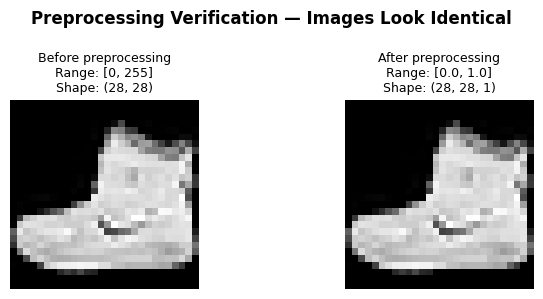

Original label    : 9  (Ankle Boot)
One-hot encoded   : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
Active position   : 9  (matches label 9)
Saved: outputs/preprocessing_check.png


In [9]:
# Preprocessing verification 
# Images should look identical before and after — only the number range changes
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

axes[0].imshow(X_train_raw[0], cmap='gray')
axes[0].set_title(
    f'Before preprocessing\nRange: [0, 255]\nShape: {X_train_raw[0].shape}',
    fontsize=9)
axes[0].axis('off')

axes[1].imshow(X_train[0].reshape(28, 28), cmap='gray')
axes[1].set_title(
    f'After preprocessing\nRange: [0.0, 1.0]\nShape: {X_train[0].shape}',
    fontsize=9)
axes[1].axis('off')

plt.suptitle('Preprocessing Verification — Images Look Identical', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/preprocessing_check.png', dpi=150, bbox_inches='tight')
plt.show()

# Verify one-hot encoding
print(f'Original label    : {y_train_raw[0]}  ({CLASS_NAMES[y_train_raw[0]]})')
print(f'One-hot encoded   : {y_train_ohe[0]}')
print(f'Active position   : {np.argmax(y_train_ohe[0])}  (matches label {y_train_raw[0]})')
print('Saved: outputs/preprocessing_check.png')

In [10]:
# Train / Validation split 
# FIX: Shuffle BEFORE splitting to ensure the validation set contains
# a representative mix of all 10 classes (Fashion-MNIST is sorted by class).

VAL_SPLIT = 0.1   # 10% of training data -> 6,000 validation images

# Shuffle indices with fixed seed for reproducibility
indices              = np.random.permutation(len(X_train))
X_train_shuffled     = X_train[indices]
y_train_ohe_shuffled = y_train_ohe[indices]
y_train_raw_shuffled = y_train_raw[indices]

val_size = int(len(X_train_shuffled) * VAL_SPLIT)

X_val,  y_val_ohe  = X_train_shuffled[:val_size],  y_train_ohe_shuffled[:val_size]
X_tr,   y_tr_ohe   = X_train_shuffled[val_size:],  y_train_ohe_shuffled[val_size:]
y_tr_raw            = y_train_raw_shuffled[val_size:]
y_val_raw           = y_train_raw_shuffled[:val_size]

print('Train / Validation Split')
print('=' * 36)
print(f'  Train samples : {X_tr.shape[0]:,}')
print(f'  Val samples   : {X_val.shape[0]:,}')
print(f'  Test samples  : {X_test.shape[0]:,}')

# Confirm val set is balanced after shuffle
val_labels = np.argmax(y_val_ohe, axis=1)
val_counts = np.bincount(val_labels)
print(f'\nVal set class counts (should be ~600 each): {val_counts}')

Train / Validation Split
  Train samples : 54,000
  Val samples   : 6,000
  Test samples  : 10,000

Val set class counts (should be ~600 each): [597 608 611 587 627 621 619 550 590 590]


In [11]:
#Save Processed Data to data/fashion_mnist/processed/ 
PROCESSED_DIR = '../data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

np.savez_compressed(f'{PROCESSED_DIR}/X_train.npz', X=X_tr)
np.savez_compressed(f'{PROCESSED_DIR}/X_val.npz',   X=X_val)
np.savez_compressed(f'{PROCESSED_DIR}/X_test.npz',  X=X_test)
np.savez_compressed(f'{PROCESSED_DIR}/y_train.npz', y_ohe=y_tr_ohe,  y_raw=y_tr_raw)
np.savez_compressed(f'{PROCESSED_DIR}/y_val.npz',   y_ohe=y_val_ohe, y_raw=y_val_raw)
np.savez_compressed(f'{PROCESSED_DIR}/y_test.npz',  y_ohe=y_test_ohe, y_raw=y_test_raw)

print('Processed data saved to data/fashion_mnist/processed/')
print('=' * 55)
files = ['X_train.npz','X_val.npz','X_test.npz',
         'y_train.npz','y_val.npz','y_test.npz']
for f in files:
    size = os.path.getsize(f'{PROCESSED_DIR}/{f}') / (1024*1024)
    print(f'  {f:<20} {size:.1f} MB')

Processed data saved to data/fashion_mnist/processed/
  X_train.npz          33.3 MB
  X_val.npz            3.7 MB
  X_test.npz           6.2 MB
  y_train.npz          0.1 MB
  y_val.npz            0.0 MB
  y_test.npz           0.0 MB


## Step 4 — Build the LeNet-5 Model

We implement LeNet-5 adapted for Fashion-MNIST's 28×28 grayscale input.
Two convolutional blocks extract spatial features; three fully connected
layers perform classification. Key modifications from the original 1998 paper:
- **ReLU** replaces sigmoid/tanh — faster training, avoids vanishing gradients
- **Dropout (0.3)** added after Dense layers — prevents overfitting

Architecture with `padding='valid'` on both Conv layers:
```
INPUT   28×28×1
  │
Conv2D(6, 5×5, valid, ReLU)   →  24×24×6
AveragePooling2D(2×2)         →  12×12×6
  │
Conv2D(16, 5×5, valid, ReLU)  →   8×8×16
AveragePooling2D(2×2)         →   4×4×16  =  256
  │
Flatten                        →  256
Dense(120, ReLU) + Dropout(0.3)
Dense(84,  ReLU) + Dropout(0.3)
Dense(10,  Softmax)            ←  output

In [12]:
def build_lenet5(input_shape=(28, 28, 1), num_classes=10):
    """LeNet-5 adapted for Fashion-MNIST with ReLU activations and Dropout."""
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        # ── Block 1 ────────────────────────────────────────────────────────────
        # 6 filters learn low-level features: edges, corners, curves
        # padding='valid' shrinks 28×28 → 24×24
        layers.Conv2D(6, kernel_size=(5, 5), padding='valid',
                      activation='relu', name='conv1'),
        # AveragePooling: 24×24 → 12×12 — reduces computation, adds shift-tolerance
        layers.AveragePooling2D(pool_size=(2, 2), strides=2, name='pool1'),

        # ── Block 2 ────────────────────────────────────────────────────────────
        # 16 filters learn higher-level features: textures, shapes
        # padding='valid' shrinks 12×12 → 8×8
        layers.Conv2D(16, kernel_size=(5, 5), padding='valid',
                      activation='relu', name='conv2'),
        # AveragePooling: 8×8 → 4×4  →  4×4×16 = 256 values
        layers.AveragePooling2D(pool_size=(2, 2), strides=2, name='pool2'),

        # ── Classifier ─────────────────────────────────────────────────────────
        # Flatten converts 3D volume (4×4×16=256) → 1D vector
        # Dense layers cannot process 3D input — Flatten is required
        layers.Flatten(name='flatten'),

        # F5: 120 neurons — learns combinations of spatial features
        layers.Dense(120, activation='relu', name='fc1'),
        # Dropout: randomly disables 30% of neurons during training
        # Forces redundancy — prevents the model memorising training data
        layers.Dropout(0.3, name='dropout1'),

        # F6: 84 neurons — further refines the representation
        layers.Dense(84, activation='relu', name='fc2'),
        layers.Dropout(0.3, name='dropout2'),

        # Output: 10 neurons (one per class)
        # Softmax converts raw scores → probabilities that sum to 1.0
        layers.Dense(num_classes, activation='softmax', name='output'),

    ], name='LeNet-5')
    return model


model = build_lenet5()
model.summary()

Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (AveragePooling2D)        │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (AveragePooling2D)        │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ── Parameter count ────────────────────────────────────────────────────────────
total_params = model.count_params()
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {total_params:,}')
print()
print('LeNet-5 is intentionally lightweight — well-suited for 28×28 grayscale images.')
print('Compare: VGG-16 has ~138 million parameters.')

Total parameters     : 44,426
Trainable parameters : 44,426

LeNet-5 is intentionally lightweight — well-suited for 28×28 grayscale images.
Compare: VGG-16 has ~138 million parameters.


## Step 5 — Compile & Train

We compile with:
- **Adam optimizer** — adaptive learning rate, converges faster than SGD
- **Categorical Crossentropy** — correct loss for multi-class one-hot targets
- **Accuracy** — easy to interpret metric for classification

Three callbacks protect training quality:
- **ModelCheckpoint** — saves weights only when `val_accuracy` improves
- **EarlyStopping** — stops if `val_loss` doesn't improve for 5 epochs
- **ReduceLROnPlateau** — halves learning rate when stuck for 3 epochs

In [14]:
# ── Compile ────────────────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled!')
print('  Optimizer : Adam  (lr = 0.001)')
print('  Loss      : Categorical Crossentropy')
print('  Metric    : Accuracy')

Model compiled!
  Optimizer : Adam  (lr = 0.001)
  Loss      : Categorical Crossentropy
  Metric    : Accuracy


In [15]:
# ── Callbacks ──────────────────────────────────────────────────────────────────

# Saves model to models/ folder whenever val_accuracy improves
cb_checkpoint = callbacks.ModelCheckpoint(
    filepath='models/best_lenet5_fashion.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1,
)

# Stops training if val_loss hasn't improved for 5 consecutive epochs
# restore_best_weights=True rolls the model back to the best epoch
cb_early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

# Halves the learning rate when val_loss plateaus for 3 epochs
# Allows finer weight adjustments near convergence
cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1,
)

EPOCHS     = 30
BATCH_SIZE = 64

print(f'Callbacks ready. Training for up to {EPOCHS} epochs (batch size {BATCH_SIZE}).')

Callbacks ready. Training for up to 30 epochs (batch size 64).


In [16]:
# ── Train ──────────────────────────────────────────────────────────────────────
history = model.fit(
    X_tr, y_tr_ohe,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val_ohe),
    callbacks=[cb_checkpoint, cb_early_stop, cb_reduce_lr],
    verbose=1,
)

print('\nTraining complete!')

Epoch 1/30
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5982 - loss: 1.0906
Epoch 1: val_accuracy improved from None to 0.79517, saving model to models/best_lenet5_fashion.keras

Epoch 1: finished saving model to models/best_lenet5_fashion.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7034 - loss: 0.7931 - val_accuracy: 0.7952 - val_loss: 0.5218 - learning_rate: 0.0010
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7913 - loss: 0.5572
Epoch 2: val_accuracy improved from 0.79517 to 0.83567, saving model to models/best_lenet5_fashion.keras

Epoch 2: finished saving model to models/best_lenet5_fashion.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8025 - loss: 0.5296 - val_accuracy: 0.8357 - val_loss: 0.4449 - learning_rate: 0.0010
Epoch 3/30
838/844 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8264 - loss: 0.4779
Epoch 3: val_accuracy improved from 0.83567 to 0.85033, saving model to models/best_lenet5_fashion.keras

Epoch 3: fi

In [17]:
# ── Training summary ───────────────────────────────────────────────────────────
best_epoch    = np.argmax(history.history['val_accuracy']) + 1
best_val_acc  = max(history.history['val_accuracy'])
final_tr_acc  = history.history['accuracy'][-1]
epochs_ran    = len(history.history['accuracy'])
gap           = final_tr_acc - best_val_acc

print('=' * 46)
print('           Training Summary')
print('=' * 46)
print(f'  Epochs ran        : {epochs_ran} / {EPOCHS}')
print(f'  Best epoch        : {best_epoch}')
print(f'  Best val accuracy : {best_val_acc*100:.2f}%')
print(f'  Final train acc   : {final_tr_acc*100:.2f}%')
print(f'  Overfitting gap   : {gap*100:.2f}%')
print('=' * 46)

if gap < 0.05:
    print('  Good fit — train and val accuracy are close.')
elif gap < 0.10:
    print('  Mild overfitting — acceptable for this architecture.')
else:
    print('  Overfitting detected — Dropout is limiting the gap.')

           Training Summary
  Epochs ran        : 30 / 30
  Best epoch        : 30
  Best val accuracy : 90.60%
  Final train acc   : 92.42%
  Overfitting gap   : 1.82%
  Good fit — train and val accuracy are close.
